In [1]:
# Needed to import and manipulate data
import pandas as pd
# Needed to create graphs
import matplotlib.pyplot as plt
# Needed for correlations
from scipy.stats import pearsonr, spearmanr, f_oneway, ttest_ind
import scipy
#k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
# Train-test split
from sklearn.model_selection import train_test_split
# Accuracy Score
from sklearn.metrics import accuracy_score
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Import dataset
nba_data = pd.read_csv("nba_stats.csv")

## Q1

In [3]:
# Clean data and drop any null values
nba_data.info()
nba_data.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RANK    213 non-null    int64  
 1   NAME    213 non-null    object 
 2   TEAM    213 non-null    object 
 3   POS     213 non-null    object 
 4   AGE     213 non-null    float64
 5   GP      213 non-null    int64  
 6   MPG     213 non-null    float64
 7   USG%    213 non-null    float64
 8   TO%     213 non-null    float64
 9   FTA     213 non-null    int64  
 10  FT%     213 non-null    float64
 11  2PA     213 non-null    int64  
 12  2P%     213 non-null    float64
 13  3PA     213 non-null    int64  
 14  3P%     213 non-null    float64
 15  eFG%    213 non-null    float64
 16  TS%     213 non-null    float64
 17  PPG     213 non-null    float64
 18  RPG     213 non-null    float64
 19  APG     213 non-null    float64
 20  SPG     213 non-null    float64
 21  BPG     213 non-null    float64
 22  TP

,RANK,NAME,TEAM,POS,AGE,GP,MPG,USG%,TO%,FTA,...,APG,SPG,BPG,TPG,P+R,P+A,P+R+A,VI,ORtg,DRtg
0,1,Joel Embiid,Phi,C,30.2,6,41.4,35.7,15.8,78,...,5.7,1.2,1.5,4.2,43.8,38.7,49.5,12.2,117.1,108.0
1,2,Jalen Brunson,Nyk,G,27.8,13,39.8,36.4,9.3,120,...,7.5,0.8,0.2,2.7,35.7,39.8,43.2,9.3,114.8,114.7
2,3,Damian Lillard,Mil,G,33.9,4,39.1,31.4,10.0,38,...,5.0,1.0,0.0,2.3,34.5,36.3,39.5,8.2,127.6,115.7
3,4,Shai Gilgeous-Alexander,Okc,G,25.9,10,39.9,32.3,8.9,81,...,6.4,1.3,1.7,2.2,37.4,36.6,43.8,11.2,118.3,106.9
4,5,Tyrese Maxey,Phi,G,23.6,6,44.6,28.1,8.6,28,...,6.8,0.8,0.3,2.2,35.0,36.7,41.8,9.1,120.9,113.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,209,David Roddy,Pho,F,23.2,2,1.4,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
209,210,Gordon Hayward,Okc,F,34.2,7,6.6,3.0,0.0,0,...,0.4,0.1,0.1,0.0,1.9,0.4,2.3,0.0,76.5,108.0
210,211,Thaddeus Young,Pho,F,36.0,1,3.6,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
211,212,T.J. Warren,Min,F,30.8,3,3.8,8.1,0.0,0,...,0.3,0.0,0.0,0.0,1.0,0.3,1.3,0.0,0.0,0.0


In [4]:
# Create function to categorize main positions to numerical values
def pos_category (pos):
    """
    Converts the position to a cateogorical variable,
    where 0 represents a guard main position, a 1 represents a
    forward main position, and a 2 represents a center main position.
    Input:
        ha (float): the position of the player
    Returns:
        0/1/2 (int): the label for the categorical variable
    """
    if pos == 'G' or pos == 'G-F':
        return "Guard" # This represents guard at main position
    elif pos == 'F' or pos == 'F-G' or pos == 'F-C':
        return "Forward" # This represents forward at main position
    else:
        return "Center" # This represents center at main position

In [5]:
# Apply function to every entry
nba_data["POS_category"] = nba_data["POS"].map(pos_category)

In [6]:
# Group age and defensive rating by position and find mean, median, std
age_stats = nba_data.groupby("POS_category")[["AGE"]].agg(["mean", "median", "std"])
print("Age Stats for each Position:", age_stats)
drtg_stats = nba_data.groupby("POS_category")[["DRtg"]].agg(["mean", "median", "std"])
print("Defensive Rating Stats for each Position:", drtg_stats)

Age Stats for each Position:                     AGE                 
                   mean median       std
POS_category                            
Center        27.993939   26.9  4.178587
Forward       27.957471   26.9  4.733813
Guard         27.444086   27.0  4.584673
Defensive Rating Stats for each Position:                    DRtg                  
                   mean median        std
POS_category                             
Center        98.748485  105.6  26.738550
Forward       84.440230  106.3  45.237902
Guard         99.351613  109.6  33.017277


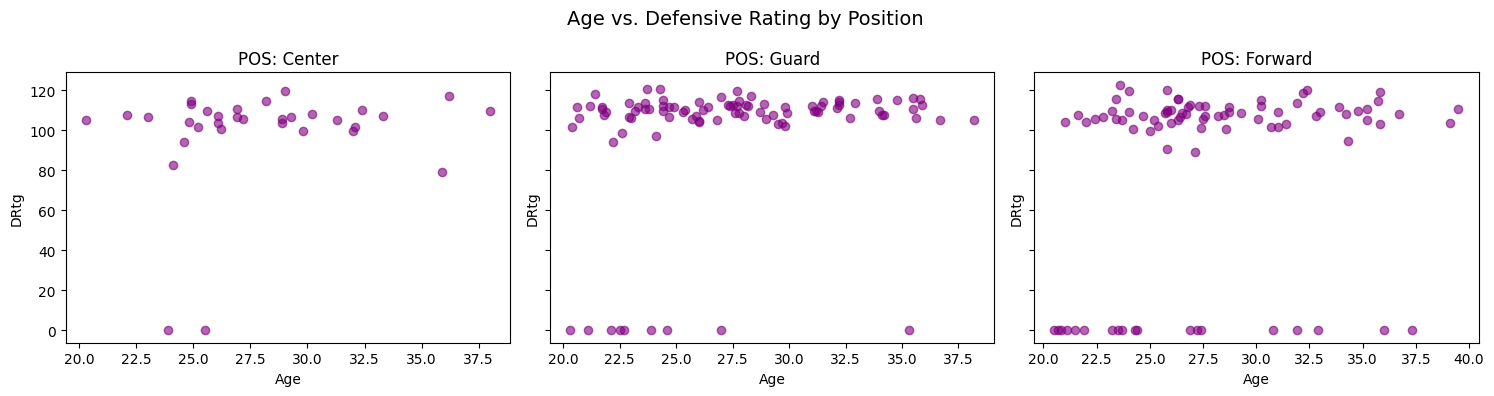

In [7]:
# Get unique positions
positions = nba_data['POS_category'].unique()

# Create scatter plots for each position
fig, axes = plt.subplots(1, len(positions), figsize=(5 * len(positions), 4), sharey=True)

for i, pos in enumerate(positions):
    subset = nba_data[nba_data['POS_category'] == pos]
    axes[i].scatter(subset["AGE"], subset["DRtg"], alpha=0.6, color="purple")
    axes[i].set_title(f"POS: {pos}")
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("DRtg")

fig.suptitle("Age vs. Defensive Rating by Position", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Find Pearon's and Spearman's correlation coefficients for each position
# Source: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
print("Correlation Results by Position:")
for pos in positions:
    subset = nba_data[nba_data['POS_category'] == pos]
    pearson_corr, _ = pearsonr(subset["AGE"], subset["DRtg"])
    spearman_corr, _ = spearmanr(subset["AGE"], subset["DRtg"])
    print(f"{pos}: Pearson = {pearson_corr:.2f}, Spearman = {spearman_corr:.2f}")

Correlation Results by Position:
Center: Pearson = 0.19, Spearman = 0.19
Guard: Pearson = 0.23, Spearman = 0.22
Forward: Pearson = 0.21, Spearman = 0.23


In [9]:
# Split age by position
# Source for test: https://www.kaggle.com/code/hamelg/python-for-data-26-anova
ages_by_pos = [nba_data[nba_data['POS_category'] == pos]["AGE"] for pos in positions]

# Run one-way ANOVA
anova_result = f_oneway(*ages_by_pos)
print(f"\nANOVA Result (Age ~ Position): p = {anova_result.pvalue:.4f}")
# Seeing that the p value is way greater than .05, we can assume there is a not a siginifcant difference
# between age and defensive rating.
# Conclusion: Age does not affect a player's defensive rating very much.


ANOVA Result (Age ~ Position): p = 0.7109


## Q2

In [10]:
# Find mean, median, std for 3PA and TS%
three_stats = nba_data["3PA"].agg(["mean", "median", "std"])
print("3PA Stats:\n", three_stats)
ts_stats = nba_data["TS%"].agg(["mean", "median", "std"])
print("True Shooting % Stats:\n", ts_stats)

3PA Stats:
 mean      24.985915
median    13.000000
std       32.278633
Name: 3PA, dtype: float64
True Shooting % Stats:
 mean      0.504197
median    0.544000
std       0.207132
Name: TS%, dtype: float64


In [11]:
# Create linear regession line
linear_model = scipy.stats.linregress(nba_data["3PA"], nba_data["TS%"])
slope = linear_model.slope
intercept = linear_model.intercept
linear_fit = slope*nba_data["3PA"]+intercept

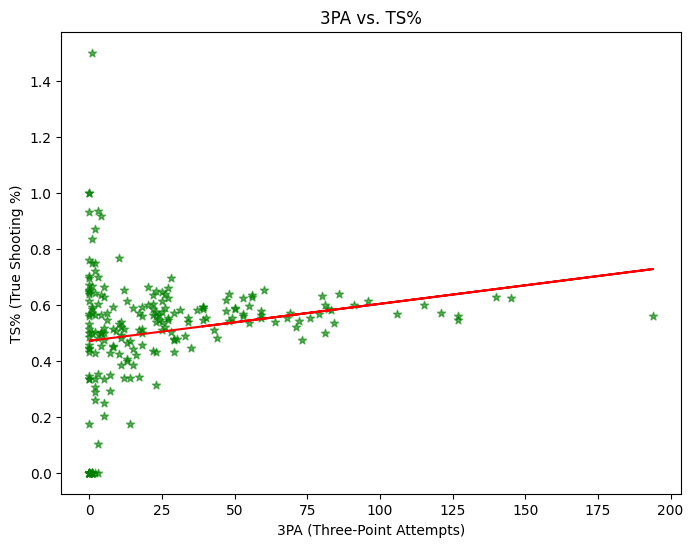

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(nba_data["3PA"], nba_data["TS%"], alpha=0.6, marker="*", color="green")
plt.plot(nba_data["3PA"], linear_fit, color="red")
plt.title("3PA vs. TS%")
plt.xlabel("3PA (Three-Point Attempts)")
plt.ylabel("TS% (True Shooting %)")
plt.show()

In [13]:
# Find Pearson's and Spearman's correlation
pearson_corr, _ = pearsonr(nba_data["3PA"], nba_data["TS%"])
spearman_corr, _ = spearmanr(nba_data["3PA"], nba_data["TS%"])

print("Pearson Correlation:", pearson_corr)
print("Spearman Correlation:", spearman_corr)
# A positive light correlation

Pearson Correlation: 0.2058551492937118
Spearman Correlation: 0.23147565009873383


In [14]:
# Two-Sample T-test using High vs. Low 3PA clusters
# Median split
median_3pa = nba_data["3PA"].median()
# Create low and high
low_3pa = nba_data[nba_data["3PA"] <= median_3pa]["TS%"]
high_3pa = nba_data[nba_data["3PA"] > median_3pa]["TS%"]

# T-test to compare means
t_stat, p_val = ttest_ind(low_3pa, high_3pa)
print("T-test comparing TS% between low and high 3PA groups:")
print(f"t = {t_stat:.3f}, p = {p_val:.4f}")
# Since p value less than .05, we have strong evidence that the two groups have different means.
# Conclusion: Higher the 3PA, better chance to have a standard true shooting %

T-test comparing TS% between low and high 3PA groups:
t = -3.166, p = 0.0018


## Q3

Model Accuracy: 0.44


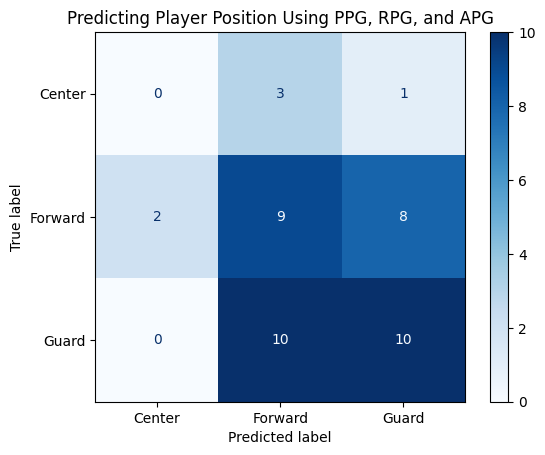

In [15]:
# Source for RandomForestClassifier: https://www.datacamp.com/tutorial/random-forests-classifier-python
# Create variables
X = nba_data[["PPG", "APG", "RPG"]]
y = nba_data["POS_category"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict and plot confusion matrix
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Predicting Player Position Using PPG, RPG, and APG")
plt.show()

In [16]:
# Cross-Validation and Manual Grid Search to improve accuracy
# Same source as Random Forest Classifier
# Define hyperparameter grid
n_estimators_list = [50, 100, 150]
max_depth_list = [None, 5, 10]

# To store results
results = []

# Loop through all combinations
for n in n_estimators_list:
    for depth in max_depth_list:
        accuracies = []

        # 5 random splits for pseudo-cross-validation
        for i in range(5):
            X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=i)

            model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            accuracies.append(acc)

        avg_acc = sum(accuracies) / len(accuracies)
        results.append((n, depth, avg_acc))
        print(f"n_estimators={n}, max_depth={depth}, Avg Accuracy={avg_acc:.4f}")


n_estimators=50, max_depth=None, Avg Accuracy=0.5581
n_estimators=50, max_depth=5, Avg Accuracy=0.5442
n_estimators=50, max_depth=10, Avg Accuracy=0.5488
n_estimators=100, max_depth=None, Avg Accuracy=0.5488
n_estimators=100, max_depth=5, Avg Accuracy=0.5442
n_estimators=100, max_depth=10, Avg Accuracy=0.5581
n_estimators=150, max_depth=None, Avg Accuracy=0.5535
n_estimators=150, max_depth=5, Avg Accuracy=0.5256
n_estimators=150, max_depth=10, Avg Accuracy=0.5535


Model Accuracy: 0.93


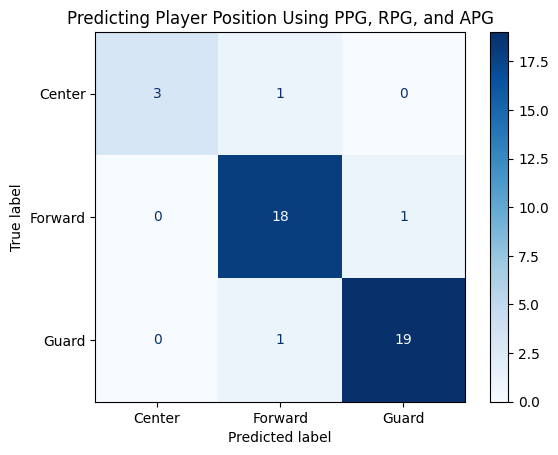

In [17]:
# Redo Test
# Train model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predict and plot confusion matrix
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Predicting Player Position Using PPG, RPG, and APG")
plt.show()
# Conclusion: After hyperparameter tuning, it could guess 93% correct, so a player's
# posisiton can be accuractely predicted based on their bulk stats (PPG, APG, RPG)